In [379]:
"""
import numpy as np

def make_state(step, steps, spot, strike):
    time_fraction = step / steps
    time_to_expiry = 1.0 - time_fraction
    moneyness = spot / strike
    return np.array([time_fraction, time_to_expiry, moneyness], dtype=np.float32)

def collect_episode(env, policy_fn):
    state = env.reset()
    transitions = []
    done = False

    while not done:
        action = policy_fn(state)
        next_state, reward, done, info = env.step_env(action)
        transitions.append((state, action, reward, next_state, done, info))
        state = next_state

    return transitions

import torch
import torch.nn as nn

class QNetwork(nn.Module):
    def __init__(self, state_dim=3, hidden_dim=64, action_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, x):
        return self.net(x)
    
def greedy_action(model, state):
    with torch.no_grad():
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        q_values = model(state_t)
        return int(torch.argmax(q_values, dim=1).item())
    
from collections import deque
import random

class ReplayBuffer:
    def __init__(self, capacity=50_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)
    
import torch.nn.functional as F

def compute_dqn_loss(online, target, batch, discount):
    states, actions, rewards, next_states, dones = batch

    states = torch.tensor(np.array(states), dtype=torch.float32)
    actions = torch.tensor(actions, dtype=torch.long).unsqueeze(1)
    rewards = torch.tensor(rewards, dtype=torch.float32)
    next_states = torch.tensor(np.array(next_states), dtype=torch.float32)
    dones = torch.tensor(dones, dtype=torch.float32)

    q_selected = online(states).gather(1, actions).squeeze(1)

    with torch.no_grad():
        next_q = target(next_states).max(dim=1).values
        q_target = rewards + (1.0 - dones) * discount * next_q

    return F.smooth_l1_loss(q_selected, q_target)


online = QNetwork(state_dim=3)
target = QNetwork(state_dim=3)
target.load_state_dict(online.state_dict())

optimizer = torch.optim.Adam(online.parameters(), lr=1e-3)
buffer = ReplayBuffer(capacity=50_000)

batch_size = 128
episodes = 10_000
target_update_every = 250
epsilon_start = 1.0
epsilon_min = 0.05
epsilon_decay = 0.999
updates = 0

for episode in range(episodes):
    state = env.reset()
    done = False
    epsilon = max(epsilon_min, epsilon_start * (epsilon_decay ** episode))

    while not done:
        if env.rng.random() < epsilon:
            action = int(env.rng.integers(0, 2))
        else:
            action = greedy_action(online, state)

        next_state, reward, done, info = env.step_env(action)
        buffer.push(state, action, reward, next_state, done)
        state = next_state

        if len(buffer) >= batch_size:
            batch = buffer.sample(batch_size)
            loss = compute_dqn_loss(online, target, batch, env.discount)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(online.parameters(), 5.0)
            optimizer.step()
            updates += 1

            if updates % target_update_every == 0:
                target.load_state_dict(online.state_dict())


def evaluate_policy(env_factory, policy_fn, episodes=10_000):
    discounted_rewards = []
    exercise_steps = []

    for seed in range(episodes):
        env = env_factory(seed=seed)
        state = env.reset()
        done = False
        step = 0

        while not done:
            action = policy_fn(state)
            state, reward, done, info = env.step_env(action)
            if done:
                discounted_rewards.append((env.discount ** step) * reward)
                if info["reason"] == "exercise":
                    exercise_steps.append(step)
            step += 1

    return {
        "value": float(np.mean(discounted_rewards)),
        "std_error": float(np.std(discounted_rewards) / np.sqrt(episodes)),
        "exercise_rate": len(exercise_steps) / episodes,
        "avg_exercise_step": float(np.mean(exercise_steps)) if exercise_steps else None,
    }

def policy_grid(policy_fn, steps=50, money_min=0.5, money_max=1.5, n_money=101):
    grid = []
    for step in range(steps + 1):
        row = []
        for m in np.linspace(money_min, money_max, n_money):
            state = np.array([step / steps, 1.0 - step / steps, m], dtype=np.float32)
            row.append(policy_fn(state))
        grid.append(row)
    return np.array(grid)

class PolicyNetwork(nn.Module):
    def __init__(self, state_dim=3, hidden_dim=64, action_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, x):
        logits = self.net(x)
        return torch.softmax(logits, dim=-1)
    

import random
import numpy as np
import torch

def set_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
"""

'\nimport numpy as np\n\ndef make_state(step, steps, spot, strike):\n    time_fraction = step / steps\n    time_to_expiry = 1.0 - time_fraction\n    moneyness = spot / strike\n    return np.array([time_fraction, time_to_expiry, moneyness], dtype=np.float32)\n\ndef collect_episode(env, policy_fn):\n    state = env.reset()\n    transitions = []\n    done = False\n\n    while not done:\n        action = policy_fn(state)\n        next_state, reward, done, info = env.step_env(action)\n        transitions.append((state, action, reward, next_state, done, info))\n        state = next_state\n\n    return transitions\n\nimport torch\nimport torch.nn as nn\n\nclass QNetwork(nn.Module):\n    def __init__(self, state_dim=3, hidden_dim=64, action_dim=2):\n        super().__init__()\n        self.net = nn.Sequential(\n            nn.Linear(state_dim, hidden_dim),\n            nn.ReLU(),\n            nn.Linear(hidden_dim, hidden_dim),\n            nn.ReLU(),\n            nn.Linear(hidden_dim, action_d

In [380]:
import numpy as np
import random
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from collections import deque
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [381]:
class AmericanPutEnv:
    HOLD = 0
    EXERCISE = 1
    def __init__(self,S0=100,K=100,r=0.05,sigma=0.2,T=1,steps=25,seed=42):

        self.S0 = S0
        self.K = K
        self.r = r
        self.sigma = sigma
        self.T = T
        self.steps = steps
        self.rng = np.random.default_rng(seed)

        self.dt = T / steps
        self.u = np.exp(sigma*np.sqrt(self.dt))
        self.d = 1/self.u
        self.p = (np.exp(r*self.dt)-self.d)/(self.u-self.d)
        self.discount = np.exp(-r*self.dt)

        self.reset()

    def reset(self):

        self.step = 0
        self.spot = self.S0
        self.done = False

        return self._state()

    def _state(self):
        time_fraction = self.step / self.steps
        time_to_expiry = 1.0 - time_fraction
        moneyness = self.spot / self.K
        return np.array([time_fraction,time_to_expiry,moneyness], dtype=np.float32)

    def step_env(self,action):

        if self.done:
            raise RuntimeError("Episode already finished.")

        payoff = max(self.K-self.spot,0)/self.K
        if action==self.EXERCISE:

            self.done=True

            return self._state(),payoff,True,{"reason":"exercise"}

        if action!=self.HOLD:
            raise ValueError("Invalid action.")
        
        
        
        
        x = self.rng.random()

        if x < self.p:
            self.spot *= self.u
        else:
            self.spot *= self.d
            
        self.step+=1

        if self.step>=self.steps:

            self.done=True

            payoff=max(self.K-self.spot,0)/self.K

            return self._state(),payoff,True,{"reason":"expiry"}

        return self._state(),0.0,False,{"reason":"hold"}

In [382]:
#contract parameters
S0 = 100
K = 100
r = 0.05
sigma = 0.20
T = 1.0
steps = 25
seed = 42

env = AmericanPutEnv(
    S0=S0,
    K=K,
    r=r,
    sigma=sigma,
    T=T,
    steps=steps,
    seed=seed
)

In [383]:
#Q-network 
class QNetwork(nn.Module):
    def __init__(self, state_dim=3, hidden_dim=128, action_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, x):
        return self.net(x)

In [384]:
#replay buffer 
class ReplayBuffer:
    def __init__(self, capacity=50_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)

In [385]:
#greedy action 
def greedy_action(model, state):
    with torch.no_grad():
        state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        q_values = model(state_t)
        return int(torch.argmax(q_values, dim=1).item())

In [386]:
#dqn loss
def compute_double_dqn_loss(online, target, batch, discount):
    states, actions, rewards, next_states, dones = batch

    states = torch.tensor(np.array(states), dtype=torch.float32, device=device)
    actions = torch.tensor(actions, dtype=torch.long, device=device).unsqueeze(1)
    rewards = torch.tensor(rewards, dtype=torch.float32, device=device)
    next_states = torch.tensor(np.array(next_states), dtype=torch.float32, device=device)
    dones = torch.tensor(dones, dtype=torch.float32, device=device)

    # Q(s,a) from online network
    q_selected = online(states).gather(1, actions).squeeze(1)

    with torch.no_grad():

        # Step 1: online network chooses best action
        next_actions = online(next_states).argmax(dim=1, keepdim=True)

        # Step 2: target network evaluates that action
        next_q = target(next_states).gather(1, next_actions).squeeze(1)

        q_target = rewards + (1.0 - dones) * discount * next_q

    loss = F.smooth_l1_loss(q_selected, q_target)

    return loss

In [387]:
#creating policy and target nentworks
online = QNetwork(state_dim=3).to(device)
target = QNetwork(state_dim=3).to(device)
target.load_state_dict(online.state_dict())

optimizer = torch.optim.Adam(
    online.parameters(),
    lr=0.01
)

buffer = ReplayBuffer(capacity=50000)

In [388]:
#hyperparameter tuning 
batch_size = 128
episodes = 15000
target_update_every = 50
epsilon_start = 1.0
epsilon_min = 0.05
epsilon_decay = 0.999
updates = 0

In [389]:
#training loop 
loss_history = []
for episode in range(episodes):
    state = env.reset()
    done = False
    epsilon = max(epsilon_min, epsilon_start * (epsilon_decay ** episode))

    while not done:
        if env.rng.random() < epsilon:
            action = int(env.rng.integers(0, 2))
        else:
            action = greedy_action(online, state)

        next_state, reward, done, info = env.step_env(action)
        buffer.push(state, action, reward, next_state, done)
        state = next_state

        if len(buffer) >= batch_size:
            batch = buffer.sample(batch_size)
            loss = compute_double_dqn_loss(online,target,batch,env.discount)
            loss_history.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(online.parameters(), 5.0)
            optimizer.step()
            updates += 1

            if updates % target_update_every == 0:
                target.load_state_dict(online.state_dict())

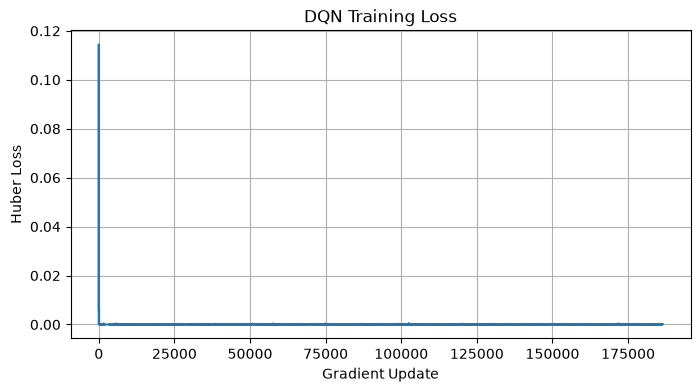

In [390]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(loss_history)
plt.xlabel("Gradient Update")
plt.ylabel("Huber Loss")
plt.title("DQN Training Loss")
plt.grid(True)
plt.show()

In [391]:
print("Replay buffer size:", len(buffer))
print("Total updates:", updates)

Replay buffer size: 50000
Total updates: 186355


In [392]:
torch.save(online.state_dict(), "american_put_dqn.pt")

In [393]:
state = np.array([0.0, 1.0, 1.0], dtype=np.float32)

with torch.no_grad():
    state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    print(online(state_t))

tensor([[0.0521, 0.0059]], device='cuda:0')


In [394]:
states = [
    np.array([0.0, 1.0, 0.20], dtype=np.float32),   # Deep ITM
    np.array([0.0, 1.0, 0.95], dtype=np.float32),   # ITM
    np.array([0.0, 1.0, 1.00], dtype=np.float32),   # ATM
    np.array([0.0, 1.0, 1.10], dtype=np.float32),   # OTM
    np.array([0.9, 0.1, 0.80], dtype=np.float32),   # Near expiry, deep ITM
]

for s in states:
    state_t = torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0)

    with torch.no_grad():
        q = online(state_t)

    print(s, q.cpu().numpy())

[0.  1.  0.2] [[0.32852176 0.4084629 ]]
[0.   1.   0.95] [[0.08370873 0.05264988]]
[0. 1. 1.] [[0.05212146 0.00593849]]
[0.  1.  1.1] [[0.02866703 0.00298171]]
[0.9 0.1 0.8] [[0.18675917 0.20504132]]


In [395]:
#Part B - creating a environment factory 
def env_factory(seed):
    return AmericanPutEnv(S0=S0,K=K,r=r,sigma=sigma,T=T,steps=steps,seed=seed)
#Baseline policies
# Always hold until expiry
def always_hold_policy(state):
    return AmericanPutEnv.HOLD
# Exercise immediately
def immediate_exercise_policy(state):
    return AmericanPutEnv.EXERCISE
# Random policy
def random_policy(state):
    return random.randint(0, 1)
# Learned DQN policy
def learned_policy(state):
    return greedy_action(online, state)

In [396]:
#evaluate policy
exercise_spots = []
def evaluate_policy(env_factory, policy_fn, episodes=5000):
    discounted_rewards = []
    exercise_steps = []
    for seed in range(episodes):
        env = env_factory(seed=seed)
        state = env.reset()
        done = False
        step = 0
        while not done:
            action = policy_fn(state)
            state, reward, done, info = env.step_env(action)
            if done:
                
                
                discount = np.exp(-env.r * env.dt * step)
                discounted_rewards.append(reward * discount)
                if info["reason"] == "exercise":
                    exercise_steps.append(step)
                    exercise_spots.append(env.spot)
            step += 1
    return {
        "value": float(np.mean(discounted_rewards)),
        "std_error": float(
            np.std(discounted_rewards) / np.sqrt(episodes)
        ),
        "exercise_rate": len(exercise_steps) / episodes,
        "avg_exercise_step":
            float(np.mean(exercise_steps))
            if exercise_steps else None,
    }

hold_results = evaluate_policy(
    env_factory,
    always_hold_policy
)

exercise_results = evaluate_policy(
    env_factory,
    immediate_exercise_policy
)

random_results = evaluate_policy(
    env_factory,
    random_policy
)

dqn_results = evaluate_policy(
    env_factory,
    learned_policy
)

In [397]:
print(np.mean(exercise_spots))

97.78421978616758


In [402]:
print("-" * 70)

print(
    f'{"Policy":<22}'
    f'{"Value":<15}'
    f'{"Exercise Rate":<18}'
    f'{"Avg Exercise Step"}'
)

print("-" * 70)

for name, result in [
    ("Always Hold", hold_results),
    ("Immediate Exercise", exercise_results),
    ("Random", random_results),
    ("Learned DQN", dqn_results),
]:

    print(
        f'{name:<22}'
        f'{result["value"]*K:<15.4f}'
        f'{result["exercise_rate"]:<18.4f}'
        f'{result["avg_exercise_step"]}'
    )

----------------------------------------------------------------------
Policy                Value          Exercise Rate     Avg Exercise Step
----------------------------------------------------------------------
Always Hold           5.6390         0.0000            None
Immediate Exercise    0.0000         1.0000            0.0
Random                1.0531         1.0000            1.0304
Learned DQN           6.0943         0.3568            12.291479820627803


In [404]:
binomial_price = 6.146185    # Replace with your own value

print("\nWeek 4 Binomial Price :", binomial_price)
print("Learned DQN Value      :", dqn_results["value"]*K) 
print("Difference             :", abs(binomial_price - dqn_results["value"]*K))


Week 4 Binomial Price : 6.146185
Learned DQN Value      : 6.094318790090292
Difference             : 0.051866209909707806


[0 1]


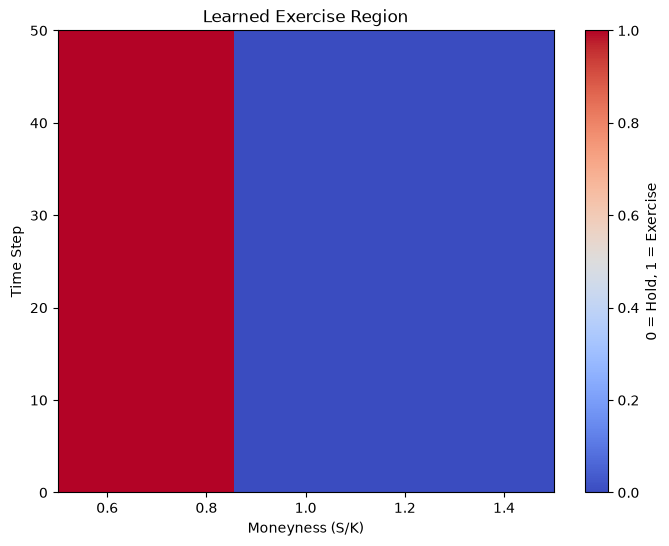

In [405]:
def policy_grid(policy_fn, steps=50, money_min=0.5, money_max=1.5, n_money=101):
    grid = []

    for step in range(steps + 1):
        row = []

        for m in np.linspace(money_min, money_max, n_money):
            state = np.array(
                [step / steps, 1.0 - step / steps, m],
                dtype=np.float32
            )

            row.append(policy_fn(state))

        grid.append(row)

    return np.array(grid)

grid = policy_grid(lambda s: greedy_action(online, s))


print(np.unique(grid))
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(
    grid,
    origin="lower",
    aspect="auto",
    extent=[0.5, 1.5, 0, 50],
    cmap="coolwarm"
)

plt.xlabel("Moneyness (S/K)")
plt.ylabel("Time Step")
plt.title("Learned Exercise Region")
plt.colorbar(label="0 = Hold, 1 = Exercise")
plt.show()

In [401]:
state = env.reset()

with torch.no_grad():
    q = online(torch.tensor(state).float().unsqueeze(0).to(device))

print(q)
print(torch.argmax(q))

tensor([[0.0521, 0.0059]], device='cuda:0')
tensor(0, device='cuda:0')
